# Component: Antarctic Peninsula

This notebook calibrates, validates, and projects the Antarctic Peninsula component of GMSL rise. Key features:
- Linear DOLS on IMBIE (1992–2020), with quadratic comparison
- BIC confirms linear model
- GMST-driven linear projection (small but positive contribution)

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-poster')

sys.path.insert(0, '.')
from slr_data_readers import read_imbie_west_antarctica
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior,
)
from slr_projections import project_component_level_ensemble
from component_analysis import apply_sigma_taper, compute_component_rates
from component_projections import read_ipcc_component_nc, ipcc_extract
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)

H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

BASELINE_YEAR = 2005.0
N_SAMPLES = 2000

## 1. Data Loading

In [2]:
# ── IMBIE Antarctic Peninsula ──
# Use read_imbie_west_antarctica for all IMBIE mm-format files — same column
# layout. Reader converts mm → m and fixes negative-sigma quirk.
df_pen = read_imbie_west_antarctica(
    f'{RAW_DIR}/ice_sheets/antarctica/imbie_antarctic_peninsula_2021_mm.csv')

# Annualize (reader output is already in meters — no further conversion)
t = df_pen['decimal_year'].values
year_int = np.floor(t).astype(int)
unique_years = np.unique(year_int)
pen_year = unique_years.astype(float) + 0.5
pen_H = np.array([df_pen['cumulative_mass_balance'].values[year_int == yr][-1]
                   for yr in unique_years])
pen_sigma = np.array([np.abs(df_pen['cumulative_mass_balance_sigma'].values[year_int == yr][-1])
                       for yr in unique_years])
bl_idx = np.argmin(np.abs(pen_year - BASELINE_YEAR))
pen_rebase = pen_H - pen_H[bl_idx]

# ── Berkeley Earth monthly temperature ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

print(f'Peninsula IMBIE: {pen_year[0]:.0f}–{pen_year[-1]:.0f}, {len(pen_year)} points')
print(f'Peninsula cumulative at end: {pen_rebase[-1]*M_TO_MM:.1f} mm')

Peninsula IMBIE: 1992–2020, 29 points
Peninsula cumulative at end: 0.8 mm


In [3]:
# ══════════════════════════════════════════════════════════════════
# REFIT SWITCH — set False to skip fitting and load saved results.
# If loading fails (no HDF5 file), fitting runs automatically.
# ══════════════════════════════════════════════════════════════════
REFIT = True

from component_io import save_apeninsula, load_component

if not REFIT:
    try:
        _loaded = load_component('apeninsula')
        pen_proj = _loaded['projections']
        PROJ_YEARS = _loaded['proj_years']
        print(f'Loaded apeninsula from HDF5: {list(pen_proj.keys())}')
    except (FileNotFoundError, KeyError) as e:
        print(f'Load failed ({e}) — falling back to REFIT=True')
        REFIT = True


## 2. Model Fitting

In [4]:
if REFIT:
    design_pen = build_level_design_vectors(
        temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
        obs_times=pen_year)

    PRIOR_SCALE_A = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.10/M_TO_MM)
    PRIOR_SCALE_B = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.20/M_TO_MM)
    prior_kw = dict(prior_scale_a=PRIOR_SCALE_A, prior_scale_b=PRIOR_SCALE_B,
                    prior_c_mean=0.0003, prior_c_sigma=0.001,
                    prior_sigma_extra_scale=0.005, prior_H0_sigma=0.005)

    result_quad = fit_bayesian_level(
        H_obs=pen_rebase, sigma_obs=pen_sigma,
        I2_obs=design_pen['I2_obs'], I1_obs=design_pen['I1_obs'],
        I0_obs=design_pen['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=200, **prior_kw)

    result_lin = fit_bayesian_level(
        H_obs=pen_rebase, sigma_obs=pen_sigma,
        I2_obs=np.zeros_like(design_pen['I2_obs']),
        I1_obs=design_pen['I1_obs'], I0_obs=design_pen['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=300, **prior_kw)

    n = len(pen_year)
    rss_q = np.sum(result_quad.residuals**2)
    rss_l = np.sum(result_lin.residuals**2)
    bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
    bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
    delta_bic = bic_l - bic_q

    a_med = np.median(result_quad.posterior_samples[:, 0]) * M_TO_MM
    b_med = np.median(result_lin.posterior_samples[:, 1]) * M_TO_MM
    c_med = np.median(result_lin.posterior_samples[:, 2]) * M_TO_MM

    print(f'Linear:    b = {b_med:.4f} mm/yr/°C, c = {c_med:.4f} mm/yr, R² = {result_lin.r2:.4f}')
    print(f'Quadratic: a = {a_med:.4f} mm/yr/°C², R² = {result_quad.r2:.4f}')
    print(f'ΔBIC = {delta_bic:+.1f} ({"quadratic" if delta_bic > 2 else "linear"} preferred)')
else:
    print('REFIT=False — skipping (loaded from HDF5)')


Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=-0.352, b=0.153, c=0.038 mm/yr, σ_extra=0.06 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 794.88it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.014  ESS_bulk=252  ESS_tail=513
    alpha0: R-hat=1.013  ESS_bulk=237  ESS_tail=701
    trend: R-hat=1.041  ESS_bulk=171  ESS_tail=799
    log_sigma_extra: R-hat=1.014  ESS_bulk=202  ESS_tail=446
    H0: R-hat=1.009  ESS_bulk=226  ESS_tail=631
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.038, b=0.072, c=0.028 mm/yr
  σ_extra: median=0.03 mm [0.00, 27.18]
  R² = -15.1101,  acceptance = 0.47
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.071, c=0.029 mm/yr, σ_extra=0.07 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 802.22it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.015  ESS_bulk=231  ESS_tail=379
    alpha0: R-hat=1.013  ESS_bulk=219  ESS_tail=706
    trend: R-hat=1.030  ESS_bulk=213  ESS_tail=530
    log_sigma_extra: R-hat=1.016  ESS_bulk=217  ESS_tail=378
    H0: R-hat=1.017  ESS_bulk=208  ESS_tail=776
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.044, b=0.058, c=0.028 mm/yr
  σ_extra: median=0.03 mm [0.00, 0.10]
  R² = 0.9403,  acceptance = 0.50
Linear:    b = 0.0561 mm/yr/°C, c = 0.0280 mm/yr, R² = 0.9403
Quadratic: a = 0.0301 mm/yr/°C², R² = -15.1101
ΔBIC = -165.7 (linear preferred)


## 3. Diagnostics & Validation

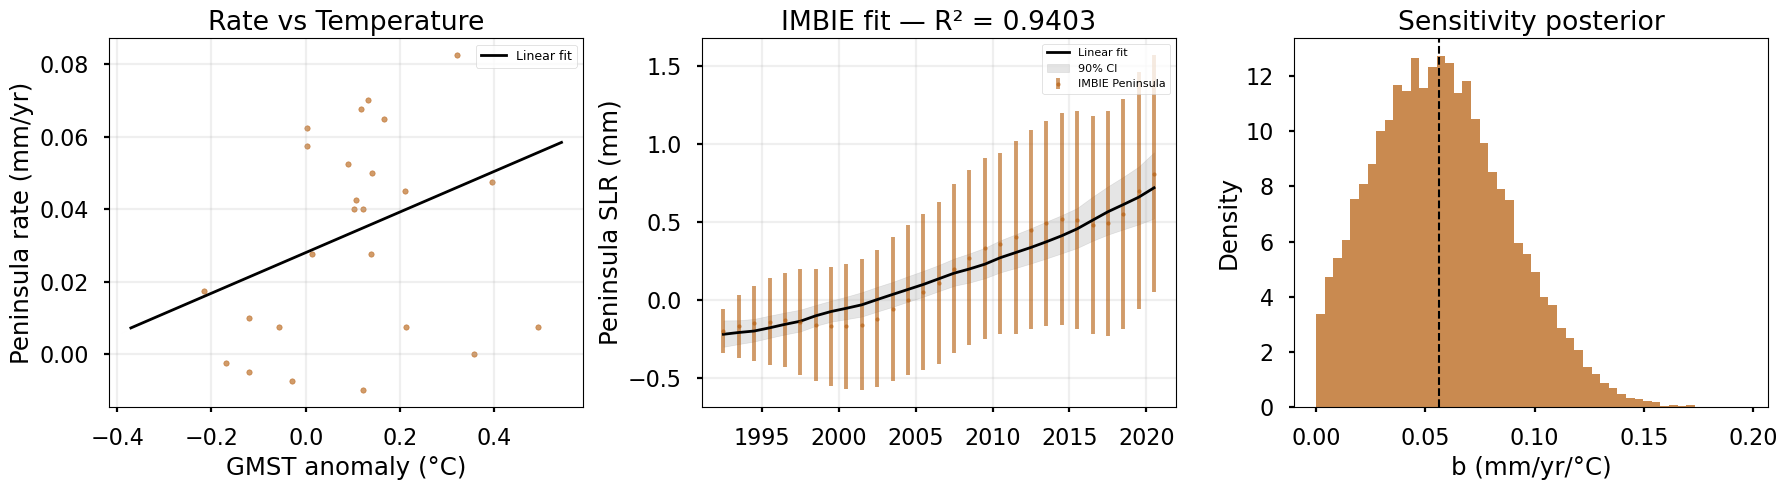

In [5]:
if REFIT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel A: Rate vs T
    ax = axes[0]
    rates = compute_component_rates(pen_year, pen_rebase, window=2) * M_TO_MM
    yr_int = np.floor(temp_time_monthly).astype(int)
    T_ann = np.array([temp_monthly[yr_int == y].mean() for y in np.unique(yr_int)])
    T_ann_years = np.unique(yr_int) + 0.5
    T_at_pen = np.interp(pen_year, T_ann_years, T_ann)
    valid = np.isfinite(rates)
    ax.scatter(T_at_pen[valid], rates[valid], s=15, alpha=0.6, color=COMP_COLORS['Peninsula'])
    T_grid = np.linspace(T_at_pen.min()-0.05, T_at_pen.max()+0.05, 100)
    ax.plot(T_grid, b_med * T_grid + c_med, 'k-', lw=2, label='Linear fit')
    ax.set_xlabel('GMST anomaly (°C)')
    ax.set_ylabel('Peninsula rate (mm/yr)')
    ax.set_title('Rate vs Temperature')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    # Panel B: IMBIE fit
    ax = axes[1]
    from component_analysis import model_ensemble_draws
    H_ens = model_ensemble_draws(result_lin, np.zeros_like(design_pen['I2_obs']),
                                  design_pen['I1_obs'], design_pen['I0_obs'])
    p5, p50, p95 = np.percentile(H_ens * M_TO_MM, [5, 50, 95], axis=0)
    ax.errorbar(pen_year, pen_rebase*M_TO_MM, yerr=2*pen_sigma*M_TO_MM,
                fmt='o', ms=3, color=COMP_COLORS['Peninsula'], alpha=0.6, label='IMBIE Peninsula')
    ax.plot(pen_year, p50, 'k-', lw=2, label='Linear fit')
    ax.fill_between(pen_year, p5, p95, color='gray', alpha=0.2, label='90% CI')
    ax.set_ylabel('Peninsula SLR (mm)')
    ax.set_title(f'IMBIE fit — R² = {result_lin.r2:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Panel C: Posteriors
    ax = axes[2]
    ax.hist(result_lin.posterior_samples[:, 1]*M_TO_MM, bins=50, density=True,
            alpha=0.7, color=COMP_COLORS['Peninsula'])
    ax.axvline(b_med, color='k', ls='--', lw=1.5)
    ax.set_xlabel('b (mm/yr/°C)')
    ax.set_ylabel('Density')
    ax.set_title('Sensitivity posterior')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_apeninsula_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('REFIT=False — skipping (loaded from HDF5)')


## 4. Projections

In [6]:
# Constants needed by downstream cells regardless of REFIT
SSP_H5_MAP = {'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
              'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5'}
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
if REFIT:
    PROJ_YEARS = np.arange(1950, 2151, dtype=float)

# Load SSP temperatures (needed for plots downstream)
df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
offset = hist_bl - temp_bl

if REFIT:
    # ── Project under each SSP ──
    pen_proj = {}
    for ssp_name, h5_key in SSP_H5_MAP.items():
        df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
        hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
        combined = pd.concat([hist_part, df_ssp]).sort_index()
        combined = combined[~combined.index.duplicated(keep='last')]
        combined['temperature'] = combined['temperature'] - offset

        t_mon = np.arange(combined['decimal_year'].min(),
                           combined['decimal_year'].max(), 1/12)
        T_mon = np.interp(t_mon, combined['decimal_year'].values,
                           combined['temperature'].values)
        T_full = np.concatenate([temp_monthly, T_mon[t_mon > temp_time_monthly[-1]]])
        t_full = np.concatenate([temp_time_monthly, t_mon[t_mon > temp_time_monthly[-1]]])

        proj = project_component_level_ensemble(
            posterior_samples=result_lin.posterior_samples,
            H0_samples=result_lin.H0_posterior,
            temperature_monthly=T_full,
            time_monthly=t_full,
            projection_times=PROJ_YEARS,
            baseline_year=BASELINE_YEAR,
            n_samples=N_SAMPLES,
            order=1,
            seed=500,
        )
        proj['median'] = np.median(proj['samples'], axis=0)
        proj['p5'] = np.percentile(proj['samples'], 5, axis=0)
        proj['p95'] = np.percentile(proj['samples'], 95, axis=0)
        proj['p17'] = np.percentile(proj['samples'], 17, axis=0)
        proj['p83'] = np.percentile(proj['samples'], 83, axis=0)
        pen_proj[ssp_name] = proj

        idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
        print(f'{ssp_name} at 2100: {proj["median"][idx_2100]*M_TO_MM:.0f} '
              f'[{proj["p5"][idx_2100]*M_TO_MM:.0f}, {proj["p95"][idx_2100]*M_TO_MM:.0f}] mm')

    # ── Save to HDF5 ──
    save_apeninsula(
        result_lin=result_lin,
        obs_years=pen_year,
        obs_H=pen_rebase,
        obs_sigma=pen_sigma,
        proj_dict=pen_proj,
        extra_metadata={'r2': float(result_lin.r2)},
    )
else:
    # Already loaded in REFIT switch cell — just print summary
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    for ssp in PROJ_SSPS:
        med = pen_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = pen_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = pen_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')


SSP1-2.6 at 2100: 7 [4, 11] mm
SSP2-4.5 at 2100: 9 [4, 15] mm
SSP3-7.0 at 2100: 10 [4, 18] mm
SSP5-8.5 at 2100: 12 [5, 21] mm
Saved apeninsula → /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5  (288583 KB total)


ISMIP6 Peninsula: 77 model-experiment runs


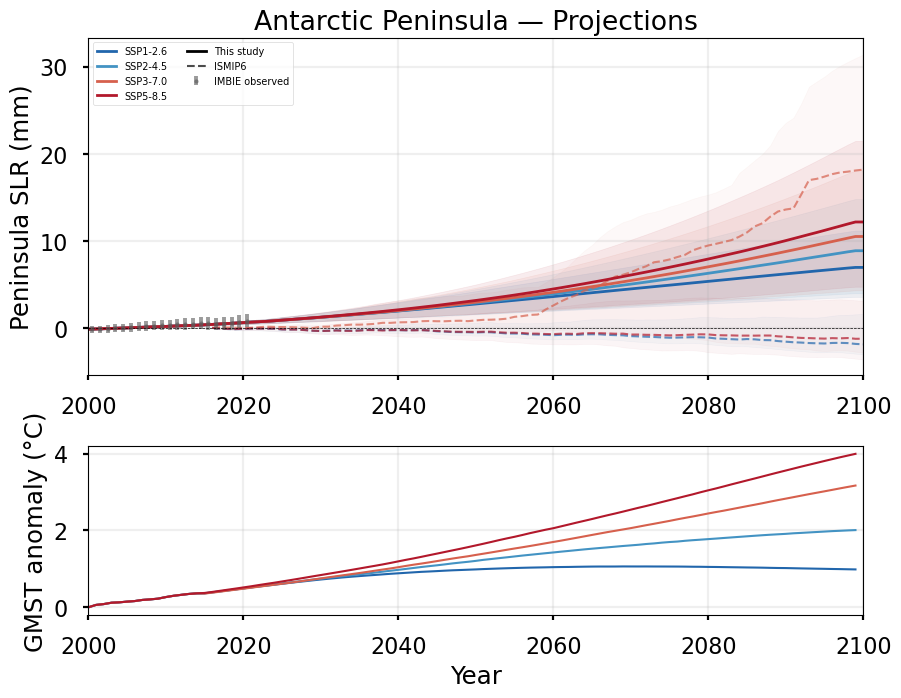

In [7]:
# ── Load ISMIP6 Peninsula data for overlay on projection plot ──
from component_projections import read_ismip6_regional, ismip6_ensemble_stats

ISMIP6_BASE = f'{RAW_DIR}/ice_sheets/ismip6/ComputedScalarsPaper'
pen_ismip6 = read_ismip6_regional(ISMIP6_BASE, region=3)
print(f'ISMIP6 Peninsula: {len(pen_ismip6)} model-experiment runs')

SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
EXP_GROUPS = {
    'SSP5-8.5': ['exp13'], 'SSP3-7.0': ['exp12'],
    'SSP1-2.6': ['exp10'], 'CMIP6 median': ['exp05', 'exp06'],
}

# Build temperature scenarios for lower panel
temp_scenarios = {}
for ssp_name, h5_key in SSP_H5_MAP.items():
    df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
    hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
    combined = pd.concat([hist_part, df_ssp]).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    combined['temperature'] = combined['temperature'] - offset
    ann = combined.groupby(combined['decimal_year'].round(0)).agg(
        temperature=('temperature', 'mean')).reset_index()
    temp_scenarios[ssp_name] = {'years': ann['decimal_year'].values,
                                 'temperature': ann['temperature'].values}

# ── Two-panel projection plot with ISMIP6 overlay ──
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 7.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.28)
ax_sl = fig.add_subplot(gs[0])
ax_t = fig.add_subplot(gs[1])

proj_mask = (PROJ_YEARS >= 2000) & (PROJ_YEARS <= 2100)
yr_plot = PROJ_YEARS[proj_mask]

for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')
    p = pen_proj[ssp]
    med = p['median'][proj_mask] * M_TO_MM
    lo = p['p5'][proj_mask] * M_TO_MM
    hi = p['p95'][proj_mask] * M_TO_MM
    ax_sl.plot(yr_plot, med, color=color, lw=2, label=f'{ssp}')
    ax_sl.fill_between(yr_plot, lo, hi, color=color, alpha=0.08)

    # ISMIP6 ensemble overlay (dashed)
    exps = EXP_GROUPS.get(ssp)
    if exps:
        stats = ismip6_ensemble_stats(pen_ismip6, experiments=exps,
                                       baseline_year=BASELINE_YEAR)
        if stats is not None:
            ax_sl.plot(stats['time'], stats['median'] * M_TO_MM,
                       color=color, ls='--', lw=1.5, alpha=0.7)
            ax_sl.fill_between(stats['time'],
                               stats['p5'] * M_TO_MM, stats['p95'] * M_TO_MM,
                               color=color, alpha=0.04)

# Observations
ax_sl.errorbar(pen_year, pen_rebase * M_TO_MM, yerr=2 * pen_sigma * M_TO_MM,
               fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax_sl.plot([], [], 'k-', lw=2, label='This study')
ax_sl.plot([], [], 'k--', lw=1.5, alpha=0.7, label='ISMIP6')
ax_sl.set_ylabel('Peninsula SLR (mm)')
ax_sl.set_title('Antarctic Peninsula — Projections')
ax_sl.legend(fontsize=7, loc='upper left', ncol=2)
ax_sl.axhline(0, color='k', lw=0.5, ls='--')
ax_sl.set_xlim(2000, 2100)
ax_sl.grid(True, alpha=0.2)

# Temperature panel
for ssp in PROJ_SSPS:
    color = SSP_COLORS.get(ssp, 'gray')
    ts = temp_scenarios[ssp]
    mask_t = (ts['years'] >= 2000) & (ts['years'] <= 2100)
    ax_t.plot(ts['years'][mask_t], ts['temperature'][mask_t], color=color, lw=1.5)
ax_t.set_ylabel('GMST anomaly (°C)')
ax_t.set_xlabel('Year')
ax_t.set_xlim(2000, 2100)
ax_t.grid(True, alpha=0.2)

plt.savefig(f'{FIG_DIR}/component_apeninsula_twopanel.png', dpi=150, bbox_inches='tight')
plt.show()

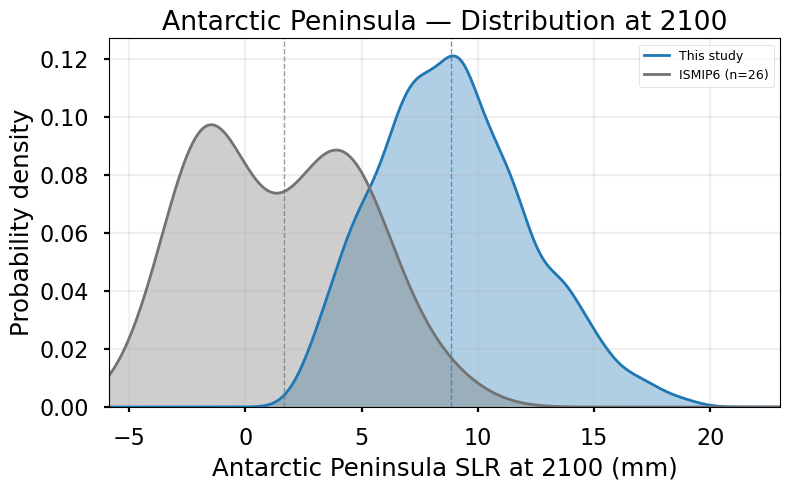

In [8]:
# ── Histogram: this study + ISMIP6 at 2100 ──
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
HIST_SSP = 'SSP2-4.5'

our_samples = pen_proj[HIST_SSP]['samples'][:, idx_2100] * M_TO_MM

# ISMIP6 Peninsula samples at 2100 (from individual model runs)
ismip6_exps = EXP_GROUPS.get(HIST_SSP, ['exp05', 'exp06'])
ismip6_vals_2100 = []
for key, val in pen_ismip6.items():
    if key[2] not in ismip6_exps:
        continue
    bl_idx = np.argmin(np.abs(val['time'] - BASELINE_YEAR))
    idx_end = np.argmin(np.abs(val['time'] - 2100))
    ismip6_vals_2100.append((val['sle_m'][idx_end] - val['sle_m'][bl_idx]) * M_TO_MM)

sample_sets = [our_samples]
labels = ['This study']
colors = ['tab:blue']
if len(ismip6_vals_2100) > 0:
    sample_sets.append(np.array(ismip6_vals_2100))
    labels.append(f'ISMIP6 (n={len(ismip6_vals_2100)})')
    colors.append('0.45')

plot_component_histogram(sample_sets, labels, colors,
                          'Antarctic Peninsula', year=2100,
                          save_path=f'{FIG_DIR}/component_apeninsula_histogram_2100.png')

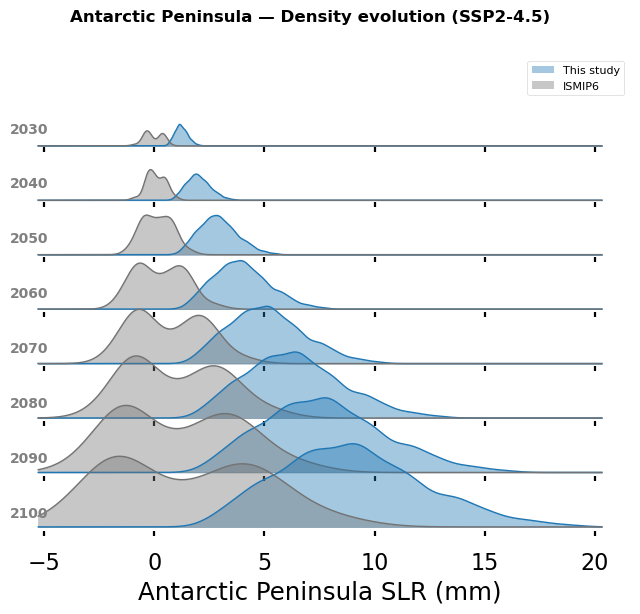

In [9]:
# ── Ridge plot: distribution evolution at decadal intervals ──
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
ismip6_exps_ridge = EXP_GROUPS.get(RIDGE_SSP, ['exp05', 'exp06'])

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    year_dict = {'This study': pen_proj[RIDGE_SSP]['samples'][:, idx_yr] * M_TO_MM}

    # ISMIP6 values at this year
    ismip6_vals = []
    for key, val in pen_ismip6.items():
        if key[2] not in ismip6_exps_ridge:
            continue
        bl_idx = np.argmin(np.abs(val['time'] - BASELINE_YEAR))
        yr_idx = np.argmin(np.abs(val['time'] - yr))
        if np.abs(val['time'][yr_idx] - yr) < 5:
            ismip6_vals.append((val['sle_m'][yr_idx] - val['sle_m'][bl_idx]) * M_TO_MM)
    if len(ismip6_vals) > 0:
        year_dict['ISMIP6'] = np.array(ismip6_vals)

    samples_by_year[yr] = year_dict

plot_component_ridge(samples_by_year, 'Antarctic Peninsula', RIDGE_SSP,
                      source_colors={'This study': 'tab:blue', 'ISMIP6': '0.45'},
                      save_path=f'{FIG_DIR}/component_apeninsula_ridge.png')

## 5. IPCC Comparison

IPCC AR6 reports Antarctic contributions as a single AIS component (EAIS + Peninsula + WAIS).
No separate Peninsula projection is available, and total AIS is dominated by WAIS uncertainty,
making a direct comparison uninformative. Peninsula contributions are evaluated as part of the
aggregate budget closure in the summary notebook.

ISMIP6 Peninsula: 77 total model-experiment runs


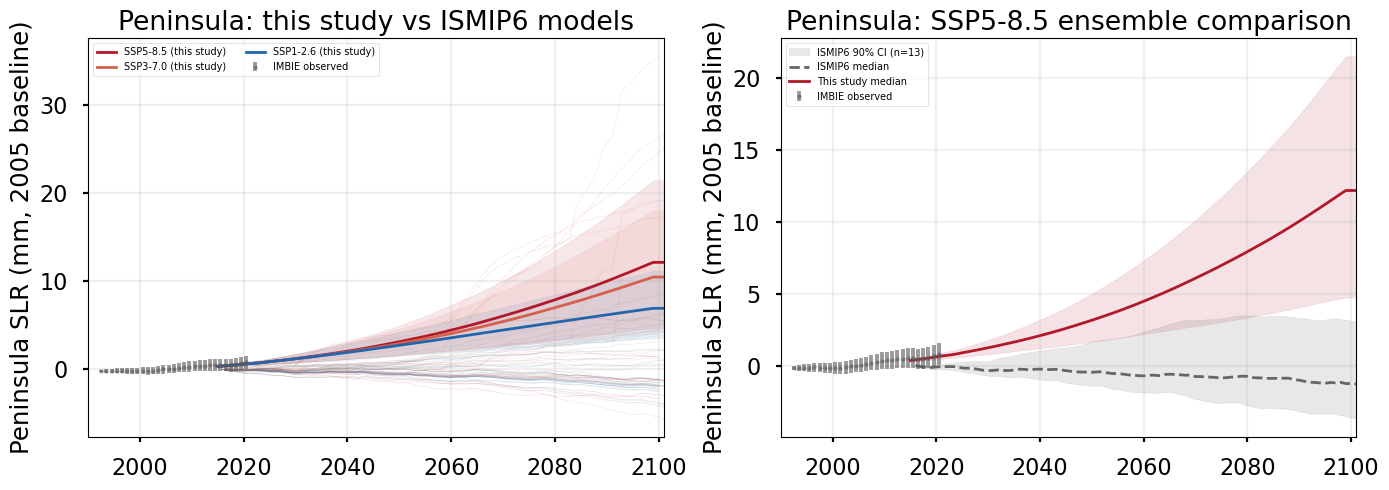


Peninsula at 2100 (mm, relative to 2005):
SSP                        This study                ISMIP6    n
SSP5-8.5                +12 [+5, +21]           -1 [-4, +3]   13
SSP3-7.0                +10 [+4, +18]         +18 [-3, +32]   10
SSP1-2.6                 +7 [+4, +11]           -2 [-3, +2]   12
CMIP6 median                                    +2 [-2, +6]   26


In [10]:
# ── ISMIP6 Peninsula comparison (ivaf_region_3) ──
from component_projections import read_ismip6_regional, ismip6_ensemble_stats

ISMIP6_BASE = f'{RAW_DIR}/ice_sheets/ismip6/ComputedScalarsPaper'

# Read all SSP-mapped experiments for Peninsula
pen_ismip6 = read_ismip6_regional(ISMIP6_BASE, region=3)
print(f'ISMIP6 Peninsula: {len(pen_ismip6)} total model-experiment runs')

# Group by SSP-relevant experiments
EXP_GROUPS = {
    'SSP5-8.5': ['exp13'],
    'SSP3-7.0': ['exp12'],
    'SSP1-2.6': ['exp10'],
    'CMIP6 median': ['exp05', 'exp06'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: ISMIP6 spaghetti + our projections
ax = axes[0]
proj_mask = (PROJ_YEARS >= 2015) & (PROJ_YEARS <= 2101)
yr_plot = PROJ_YEARS[proj_mask]

for ssp_label, exps in EXP_GROUPS.items():
    color = SSP_COLORS.get(ssp_label, 'gray')
    # ISMIP6 individual trajectories
    for key, val in pen_ismip6.items():
        if key[2] not in exps:
            continue
        t = val['time']
        sle = val['sle_m']
        bl_idx = np.argmin(np.abs(t - BASELINE_YEAR))
        sle_rb = sle - sle[bl_idx]
        ax.plot(t, sle_rb * M_TO_MM, color=color, alpha=0.15, lw=0.5)

    # Our projection
    if ssp_label in pen_proj:
        p = pen_proj[ssp_label]
        ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2,
                label=f'{ssp_label} (this study)')
        ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM,
                        p['p95'][proj_mask] * M_TO_MM, color=color, alpha=0.1)

# Observations
ax.errorbar(pen_year, pen_rebase * M_TO_MM, yerr=2 * pen_sigma * M_TO_MM,
            fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax.set_xlim(1990, 2101)
ax.set_ylabel('Peninsula SLR (mm, 2005 baseline)')
ax.set_title('Peninsula: this study vs ISMIP6 models')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.2)

# Panel B: Ensemble statistics for SSP5-8.5
ax = axes[1]
ssp_plot = 'SSP5-8.5'
exps_plot = EXP_GROUPS[ssp_plot]
stats = ismip6_ensemble_stats(pen_ismip6, experiments=exps_plot,
                               baseline_year=BASELINE_YEAR)
if stats is not None:
    color = SSP_COLORS.get(ssp_plot, 'C3')
    ax.fill_between(stats['time'], stats['p5'] * M_TO_MM, stats['p95'] * M_TO_MM,
                    color='0.7', alpha=0.3, label=f'ISMIP6 90% CI (n={stats["n_models"]})')
    ax.plot(stats['time'], stats['median'] * M_TO_MM, color='0.4', lw=2, ls='--',
            label='ISMIP6 median')

if ssp_plot in pen_proj:
    p = pen_proj[ssp_plot]
    ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM, color=color, lw=2,
            label='This study median')
    ax.fill_between(yr_plot, p['p5'][proj_mask] * M_TO_MM,
                    p['p95'][proj_mask] * M_TO_MM, color=color, alpha=0.12)

ax.errorbar(pen_year, pen_rebase * M_TO_MM, yerr=2 * pen_sigma * M_TO_MM,
            fmt='o', ms=3, color='0.35', alpha=0.6, label='IMBIE observed')
ax.set_xlim(1990, 2101)
ax.set_ylabel('Peninsula SLR (mm, 2005 baseline)')
ax.set_title(f'Peninsula: {ssp_plot} ensemble comparison')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_apeninsula_ismip6.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f'\nPeninsula at 2100 (mm, relative to {BASELINE_YEAR:.0f}):')
print(f'{"SSP":<16s} {"This study":>20s}  {"ISMIP6":>20s}  {"n":>3s}')
for ssp_label, exps in EXP_GROUPS.items():
    stats_s = ismip6_ensemble_stats(pen_ismip6, experiments=exps,
                                     baseline_year=BASELINE_YEAR)
    our = ''
    if ssp_label in pen_proj:
        idx = np.argmin(np.abs(PROJ_YEARS - 2100))
        p = pen_proj[ssp_label]
        our = f'{p["median"][idx]*M_TO_MM:+.0f} [{p["p5"][idx]*M_TO_MM:+.0f}, {p["p95"][idx]*M_TO_MM:+.0f}]'
    ism = ''
    n = 0
    if stats_s is not None:
        ism = f'{stats_s["median"][-1]*M_TO_MM:+.0f} [{stats_s["p5"][-1]*M_TO_MM:+.0f}, {stats_s["p95"][-1]*M_TO_MM:+.0f}]'
        n = stats_s['n_models']
    print(f'{ssp_label:<16s} {our:>20s}  {ism:>20s}  {n:>3d}')

## 6. Appendix: Sensitivity & Reviewer Q&A

In [11]:
F_MAX_VALUES = [1, 2, 3]

print(f'{"f_max":>5} {"a (mm/yr/°C²)":>16} {"b (mm/yr/°C)":>16} {"R²_lin":>8} {"ΔBIC":>8}')
print('-' * 60)

for f_max in F_MAX_VALUES:
    sig_tapered = apply_sigma_taper(pen_sigma, pen_year, 2005, f_max)
    res_q = fit_bayesian_level(
        H_obs=pen_rebase, sigma_obs=sig_tapered,
        I2_obs=design_pen['I2_obs'], I1_obs=design_pen['I1_obs'],
        I0_obs=design_pen['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=200+f_max*100, **prior_kw)
    res_l = fit_bayesian_level(
        H_obs=pen_rebase, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_pen['I2_obs']),
        I1_obs=design_pen['I1_obs'], I0_obs=design_pen['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=300+f_max*100, **prior_kw)

    a_s = np.median(res_q.posterior_samples[:, 0]) * M_TO_MM
    b_s = np.median(res_l.posterior_samples[:, 1]) * M_TO_MM
    rss_q = np.sum(res_q.residuals**2)
    rss_l = np.sum(res_l.residuals**2)
    bic_q = n * np.log(rss_q/n) + 5*np.log(n)
    bic_l = n * np.log(rss_l/n) + 4*np.log(n)
    print(f'{f_max:>5} {a_s:>16.4f} {b_s:>16.4f} {res_l.r2:>8.4f} {bic_l-bic_q:>+8.1f}')

f_max    a (mm/yr/°C²)     b (mm/yr/°C)   R²_lin     ΔBIC
------------------------------------------------------------
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=-0.352, b=0.153, c=0.038 mm/yr, σ_extra=0.06 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 805.54it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.050  ESS_bulk=152  ESS_tail=478
    alpha0: R-hat=1.007  ESS_bulk=241  ESS_tail=685
    trend: R-hat=1.018  ESS_bulk=225  ESS_tail=571
    log_sigma_extra: R-hat=1.013  ESS_bulk=240  ESS_tail=419
    H0: R-hat=1.023  ESS_bulk=183  ESS_tail=554
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.037, b=0.071, c=0.025 mm/yr
  σ_extra: median=0.03 mm [0.00, 7.94]
  R² = -0.4555,  acceptance = 0.47
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.071, c=0.029 mm/yr, σ_extra=0.07 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 827.97it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.020  ESS_bulk=194  ESS_tail=500
    alpha0: R-hat=1.015  ESS_bulk=231  ESS_tail=731
    trend: R-hat=1.015  ESS_bulk=187  ESS_tail=715
    log_sigma_extra: R-hat=1.016  ESS_bulk=236  ESS_tail=391
    H0: R-hat=1.016  ESS_bulk=237  ESS_tail=687
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.042, b=0.056, c=0.028 mm/yr
  σ_extra: median=0.03 mm [0.00, 0.10]
  R² = 0.9401,  acceptance = 0.50
    1           0.0288           0.0538   0.9401    -86.2
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=-0.352, b=0.153, c=0.038 mm/yr, σ_extra=0.06 mm


...

  Convergence diagnostics:
    dalpha_dT: R-hat=1.014  ESS_bulk=185  ESS_tail=424
    alpha0: R-hat=1.032  ESS_bulk=152  ESS_tail=1125
    trend: R-hat=1.018  ESS_bulk=174  ESS_tail=696
    log_sigma_extra: R-hat=1.020  ESS_bulk=216  ESS_tail=320
    H0: R-hat=1.022  ESS_bulk=175  ESS_tail=774
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.044, b=0.053, c=0.030 mm/yr
  σ_extra: median=0.04 mm [0.00, 0.13]
  R² = 0.9436,  acceptance = 0.49
    2           0.0271           0.0505   0.9436   -143.7
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=-0.352, b=0.153, c=0.038 mm/yr, σ_extra=0.06 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 817.49it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.038  ESS_bulk=122  ESS_tail=391
    alpha0: R-hat=1.046  ESS_bulk=97  ESS_tail=543
    trend: R-hat=1.022  ESS_bulk=257  ESS_tail=557
    log_sigma_extra: R-hat=1.049  ESS_bulk=131  ESS_tail=321
    H0: R-hat=1.036  ESS_bulk=123  ESS_tail=366
  WARNINGS:
  alpha0: bulk ESS = 97 < 100 — increase samples or walkers
  Posterior mean: a=0.034, b=0.065, c=0.029 mm/yr
  σ_extra: median=0.04 mm [0.00, 0.16]
  R² = 0.8921,  acceptance = 0.47
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=0.000, b=0.071, c=0.029 mm/yr, σ_extra=0.07 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 825.65it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.029  ESS_bulk=144  ESS_tail=428
    alpha0: R-hat=1.035  ESS_bulk=141  ESS_tail=686
    trend: R-hat=1.019  ESS_bulk=245  ESS_tail=764
    log_sigma_extra: R-hat=1.019  ESS_bulk=210  ESS_tail=360
    H0: R-hat=1.037  ESS_bulk=155  ESS_tail=712
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.044, b=0.048, c=0.031 mm/yr
  σ_extra: median=0.04 mm [0.00, 0.15]
  R² = 0.9433,  acceptance = 0.49
    3           0.0262           0.0453   0.9433    -20.0
